# 03 — Il golden cross regge davvero?

**Regola:** compra SPY quando la media mobile a 50 giorni sta sopra quella a 200, altrimenti stai in liquidità.
Parametri fissati in anticipo (quelli famosi), non scelti guardando i dati.

**Previsione scritta prima di vedere i risultati:** il buy & hold batte il golden cross di circa **10 punti percentuali all'anno** (rendimento annualizzato, al netto dei costi, out-of-sample).

Regole: costi inclusi, segnale usato solo dal giorno dopo, confronto sempre con buy & hold, giudizio sul periodo out-of-sample.

## 1. Dati

SPY dal primo giorno in cui esiste (29 gennaio 1993). La data di fine è fissa, così chi rilancia il notebook ottiene gli stessi numeri.

In [1]:
from quantlab.data import load_prices, validate_prices

START, END = "1993-01-29", "2026-10-01"  # fixed end date: reproducible results

spy = load_prices(["SPY"], START, END, cache_dir="../data", snapshot_dir="../market")["SPY"]

print(f"{len(spy)} trading days, from {spy.index[0].date()} to {spy.index[-1].date()}")
print("Problems found:", validate_prices(spy.to_frame()))

8475 trading days, from 1993-01-29 to 2026-09-30
Problems found: []


## 2. Il segnale a occhio

Prezzo (scala logaritmica: la stessa distanza verticale = la stessa variazione percentuale) e le due medie mobili. Le fasce grigie sono i periodi **fuori mercato** (media 50 sotto la 200).

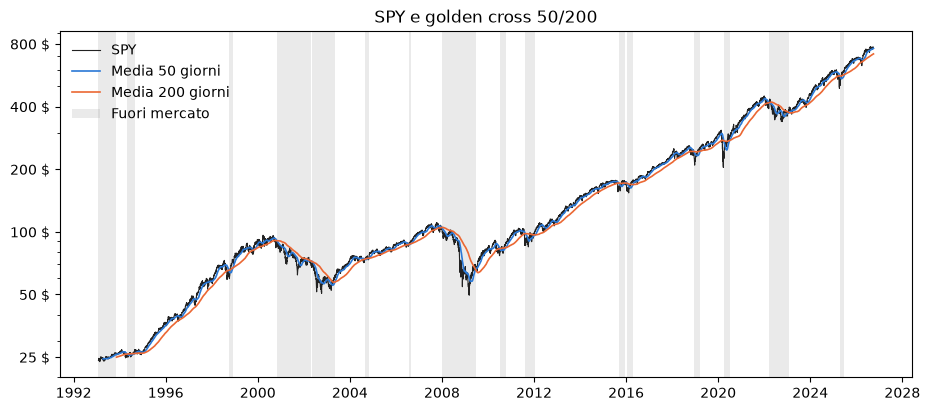

Invested 75% of the days, 31 switches in total


In [2]:
import matplotlib.pyplot as plt

from quantlab.strategies import moving_average_crossover

signal = moving_average_crossover(spy, fast=50, slow=200)  # 1 = invested, 0 = cash

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(spy, color="#222222", linewidth=0.8, label="SPY")
ax.plot(spy.rolling(50).mean(), color="#2a78d6", linewidth=1.2, label="Media 50 giorni")
ax.plot(spy.rolling(200).mean(), color="#eb6834", linewidth=1.2, label="Media 200 giorni")
# grey bands where the signal says "out": fill between bottom and top of the axis
ax.fill_between(spy.index, 0, 1, where=signal == 0, transform=ax.get_xaxis_transform(),
                color="#999999", alpha=0.2, linewidth=0, label="Fuori mercato")
ax.set_yscale("log")
ax.set_yticks([25, 50, 100, 200, 400, 800])  # round prices instead of 6x10^2
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0f} $")
ax.yaxis.set_minor_formatter(lambda v, _: "")
ax.set_title("SPY e golden cross 50/200")
ax.legend(loc="upper left", frameon=False)
plt.show()

print(f"Invested {signal.mean():.0%} of the days, {int((signal.diff().abs() == 1).sum())} switches in total")

## 3. Il backtest onesto

Una sola chiamata alla "macchina della verità" (`evaluate_strategy`):
- **costi**: 0,10% di commissione + 0,05% di slippage a ogni operazione;
- **shift**: il segnale di oggi diventa posizione domani (niente look-ahead);
- **liquidità**: quando è fuori, la strategia incassa gli interessi dei titoli di Stato a 3 mesi, in media circa 2,5% l'anno dal 1993 (dal 2000 la media di `^IRX` è 1,9%; negli anni '90 era intorno al 5%). Senza questo la penalizzeremmo ingiustamente;
- **split**: primi 70% dei giorni in-sample, ultimi 30% out-of-sample. Con parametri fissi non scegliamo nulla in-sample, ma guardare il periodo finale a parte ci dice se la regola funziona ancora oggi;
- **bootstrap**: 1000 ricampionamenti a blocchi di 20 giorni (seed 42) per capire se la differenza è fortuna.

In [3]:
from quantlab.report import evaluate_strategy, format_report

CASH_RATE = 0.025  # average 3-month T-bill yield, 1993-2026 (approx.)

report = evaluate_strategy(spy, moving_average_crossover, params={"fast": 50, "slow": 200},
                           name="golden_cross", cash_rate=CASH_RATE, seed=42)
print(format_report(report))

STRATEGY REPORT: golden_cross {'fast': 50, 'slow': 200}
Period 1993-01-29 -> 2026-09-30, out-of-sample from 2016-08-18
Costs per trade: commission 0.10%, slippage 0.05%; idle cash earns 2.50% a year (subtracted in Sharpe)

VERDICT: NO EVIDENCE it beats buy & hold: out-of-sample, the Sharpe difference is within what luck alone can produce (95% bootstrap interval contains zero).
  Out-of-sample Sharpe difference -0.13 (95% interval -0.43 to +0.23; strategy ahead in 23% of bootstrap samples)

IN-SAMPLE (used to choose parameters)
                  strategy buy_and_hold
total_return        816.8%       670.3%
annual_return         9.9%         9.1%
annual_volatility    12.9%        18.8%
sharpe                0.60         0.42
max_drawdown        -19.5%       -55.2%

OUT-OF-SAMPLE (never seen while choosing)
                  strategy buy_and_hold
total_return        188.5%       311.0%
annual_return        11.1%        15.0%
annual_volatility    15.2%        17.9%
sharpe                0.

## 4. Out-of-sample: crescita di 1 € e drawdown

Entrambe le curve partono da 1 il primo giorno out-of-sample.

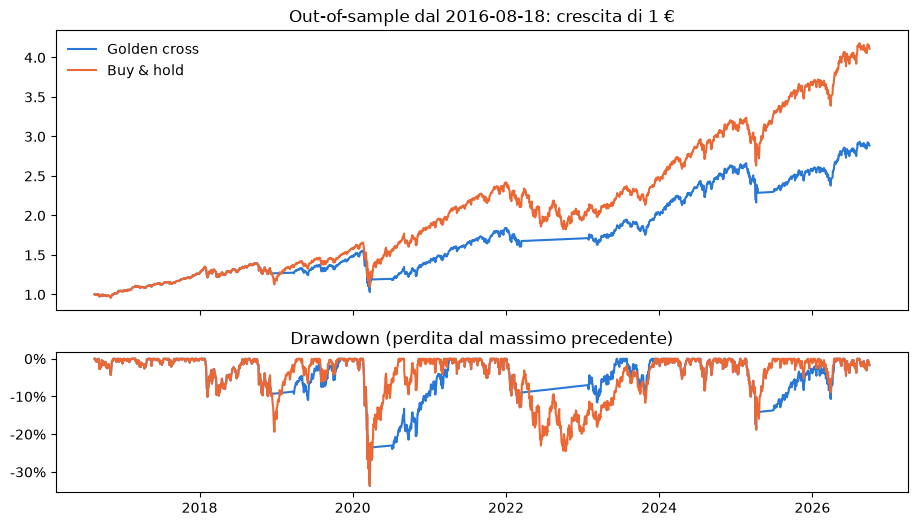

In [4]:
oos = report.returns[report.returns.index >= report.split]
equity = (1 + oos).cumprod()  # growth of 1 euro
dd = equity / equity.cummax() - 1  # drop from the previous peak

COLORS = {"strategy": "#2a78d6", "buy_and_hold": "#eb6834"}
LABELS = {"strategy": "Golden cross", "buy_and_hold": "Buy & hold"}
fig, (top, bottom) = plt.subplots(2, 1, figsize=(11, 6), sharex=True, height_ratios=[2, 1])
for col in oos.columns:
    top.plot(equity[col], color=COLORS[col], label=LABELS[col])
    bottom.plot(dd[col], color=COLORS[col])
top.set_title(f"Out-of-sample dal {report.split.date()}: crescita di 1 €")
top.legend(loc="upper left", frameon=False)
bottom.set_title("Drawdown (perdita dal massimo precedente)")
bottom.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
plt.show()

## 5. Verdetto sulla previsione

La previsione era: buy & hold avanti di circa **10 punti all'anno**.

In [5]:
for label, table in [("In-sample", report.in_sample), ("Out-of-sample", report.out_of_sample)]:
    gap = table.loc["annual_return", "buy_and_hold"] - table.loc["annual_return", "strategy"]
    print(f"{label:14} buy & hold ahead by {gap:+.1%} a year")

In-sample      buy & hold ahead by -0.8% a year
Out-of-sample  buy & hold ahead by +4.0% a year


## Conclusione

**La previsione aveva ragione sul verso, ma era troppo pessimista sulla misura.** Fuori campione (2016–2026) il buy & hold batte il golden cross di **4 punti all'anno** (15,0% contro 11,1%), non di 10.

Cosa abbiamo imparato:
1. **Nel passato la regola sembrava ottima.** Dal 1993 al 2016 rende un po' di più (9,9% contro 9,1%), con molto meno rischio: volatilità 12,9% contro 18,8% e perdita massima −19,5% contro −55,2%. Il motivo è che è uscita in tempo dai due grandi crolli lenti, quello del 2000–2002 e quello del 2008.
2. **Negli ultimi 10 anni non ha funzionato.** I crolli sono stati velocissimi (marzo 2020) o subito recuperati: la regola esce quando il danno è già fatto e rientra dopo il rimbalzo. La perdita massima è identica a quella del buy & hold (−33,7%), quindi la protezione promessa non c'è stata.
3. **Il bootstrap non permette di dire nulla di definitivo.** La differenza di Sharpe (−0,13) sta dentro l'intervallo da −0,43 a +0,23: con 10 anni di dati non si distingue dalla fortuna, né in un senso né nell'altro.
4. **I limiti.** Un solo titolo (SPY), scelto oggi sapendo che è andato bene (survivorship bias), e un tasso di liquidità medio fisso (2,5%) invece di quello vero di ogni anno.

**Il numero da battere per il machine learning:** fuori campione, Sharpe **0,73** (buy & hold) e **0,60** (golden cross).